# ODIR-5K: Khám phá dữ liệu và Tiền xử lý

Notebook này thực hiện:
1. Phân tích phân phối nhãn và nhân khẩu học
2. Minh họa phương pháp Graham (chuẩn hóa độ sáng)
3. Tính class weights cho BCEWithLogitsLoss

**Không lưu ảnh** — chỉ phân tích và trực quan hóa.

In [2]:
import os
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = '/home/centrala/work/ou/kltn/Ocular-Disease-Recognition'
DATA_XLSX    = f'{PROJECT_ROOT}/odir-data/data.xlsx'
IMAGE_DIR    = f'{PROJECT_ROOT}/odir-data/crop_training_images'
OUTPUT_DIR   = f'{PROJECT_ROOT}/model_v2'

TARGET_COLS  = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
LABEL_NAMES  = {
    'N': 'Normal',
    'D': 'Diabetic Retinopathy',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'Age-related Macular Degeneration',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Other Diseases'
}

print('Imports OK')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

Imports OK
PROJECT_ROOT: /home/centrala/work/ou/kltn/Ocular-Disease-Recognition


## 1. Load dữ liệu

In [3]:
df = pd.read_excel(DATA_XLSX)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (3500, 15)
Columns: ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1


In [4]:
# Kiểm tra cột nhãn
print('Label columns sample:')
print(df[TARGET_COLS].head(10))
print(f'\nTotal patients: {len(df)}')
print(f'Missing values:\n{df[TARGET_COLS + ["Patient Age", "Patient Sex"]].isnull().sum()}')

Label columns sample:
   N  D  G  C  A  H  M  O
0  0  0  0  1  0  0  0  0
1  1  0  0  0  0  0  0  0
2  0  1  0  0  0  0  0  1
3  0  0  0  0  0  0  0  1
4  0  1  0  0  0  0  0  1
5  0  1  0  0  0  0  0  0
6  0  1  0  0  0  0  0  1
7  0  1  0  0  0  0  0  1
8  1  0  0  0  0  0  0  0
9  0  0  0  0  0  0  0  1

Total patients: 3500
Missing values:
N              0
D              0
G              0
C              0
A              0
H              0
M              0
O              0
Patient Age    0
Patient Sex    0
dtype: int64


## 2. Phân phối nhãn bệnh

Imbalance ratio (max/min): 11.1x

Label counts:
  N (Normal): 1140 (32.6%)
  D (Diabetic Retinopathy): 1128 (32.2%)
  O (Other Diseases): 979 (28.0%)
  G (Glaucoma): 215 (6.1%)
  C (Cataract): 212 (6.1%)
  M (Myopia): 174 (5.0%)
  A (Age-related Macular Degeneration): 164 (4.7%)
  H (Hypertension): 103 (2.9%)


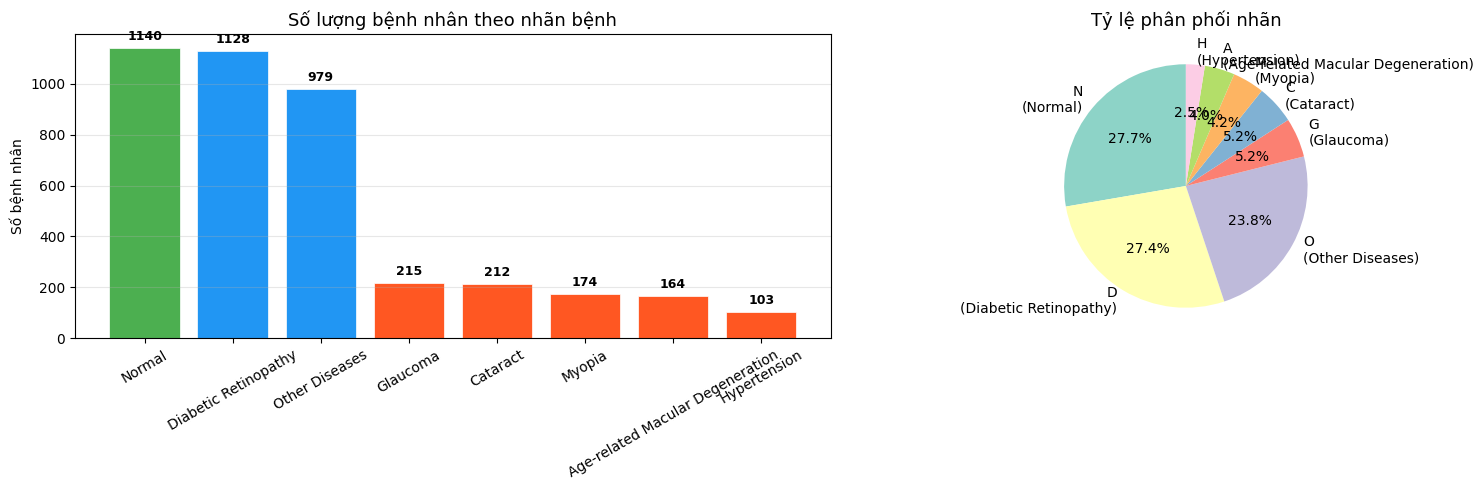

Saved: chart_label_distribution.png


In [5]:
label_counts = df[TARGET_COLS].sum().sort_values(ascending=False)
imbalance_ratio = label_counts.max() / label_counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.1f}x')
print('\nLabel counts:')
for col in label_counts.index:
    pct = df[col].mean() * 100
    print(f'  {col} ({LABEL_NAMES[col]}): {int(label_counts[col])} ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = ['#4CAF50' if c == 'N' else '#2196F3' if df[c].sum() > 500 else '#FF5722'
          for c in label_counts.index]
bars = axes[0].bar(
    [LABEL_NAMES[c] for c in label_counts.index],
    label_counts.values,
    color=colors, edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(int(val)), ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Số lượng bệnh nhân theo nhãn bệnh', fontsize=13)
axes[0].set_ylabel('Số bệnh nhân')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=[f'{c}\n({LABEL_NAMES[c]})' for c in label_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors[:len(label_counts)]
)
axes[1].set_title('Tỷ lệ phân phối nhãn', fontsize=13)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart_label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: chart_label_distribution.png')

## 3. Ma trận đồng xuất hiện nhãn (Co-occurrence)

Phân phối số nhãn trên mỗi bệnh nhân:
{1: 2914, 2: 557, 3: 29}


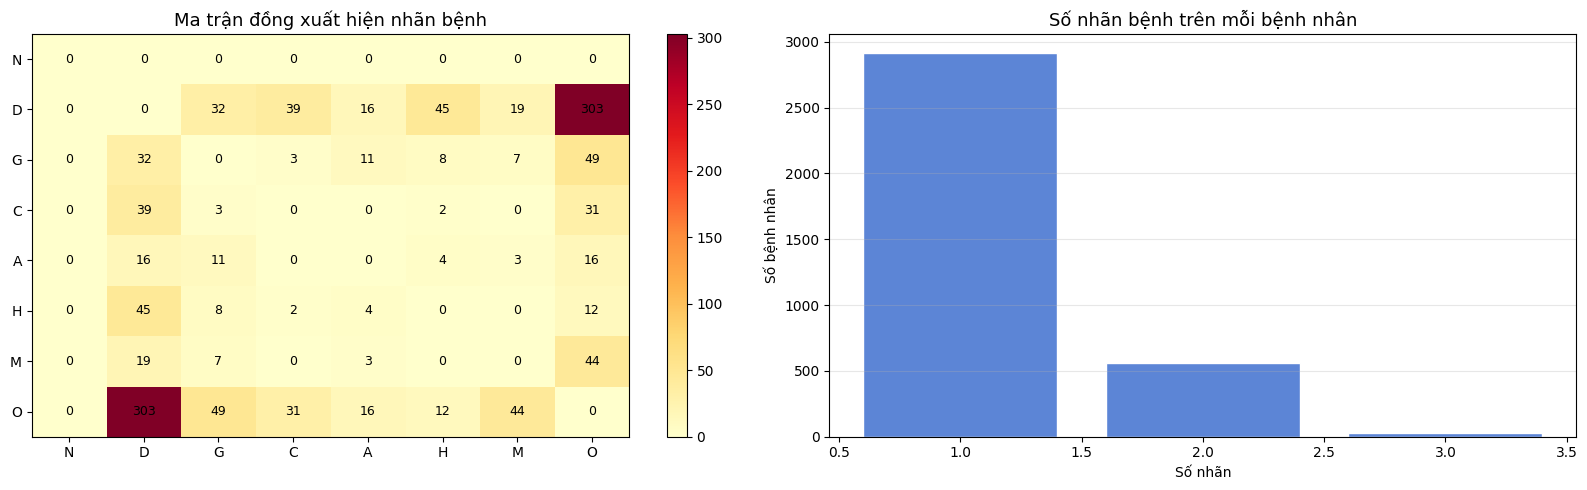

In [6]:
n_labels_per_patient = df[TARGET_COLS].sum(axis=1)
print('Phân phối số nhãn trên mỗi bệnh nhân:')
print(n_labels_per_patient.value_counts().sort_index().to_dict())

# Co-occurrence matrix
co_matrix = df[TARGET_COLS].T.dot(df[TARGET_COLS]).astype(int)
np.fill_diagonal(co_matrix.values, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Co-occurrence heatmap
im = axes[0].imshow(co_matrix.values, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(len(TARGET_COLS)))
axes[0].set_yticks(range(len(TARGET_COLS)))
axes[0].set_xticklabels(TARGET_COLS)
axes[0].set_yticklabels(TARGET_COLS)
for i in range(len(TARGET_COLS)):
    for j in range(len(TARGET_COLS)):
        axes[0].text(j, i, str(co_matrix.values[i, j]),
                     ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Ma trận đồng xuất hiện nhãn bệnh', fontsize=13)

# Số nhãn per patient distribution
axes[1].bar(n_labels_per_patient.value_counts().sort_index().index,
            n_labels_per_patient.value_counts().sort_index().values,
            color='#5C85D6', edgecolor='white')
axes[1].set_title('Số nhãn bệnh trên mỗi bệnh nhân', fontsize=13)
axes[1].set_xlabel('Số nhãn')
axes[1].set_ylabel('Số bệnh nhân')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart_multilabel.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Phân tích nhân khẩu học

Age statistics:
count    3500.000000
mean       57.854000
std        11.724064
min         1.000000
25%        51.000000
50%        59.000000
75%        66.000000
max        91.000000
Name: Patient Age, dtype: float64

Gender distribution:
Patient Sex
Male      1885
Female    1615
Name: count, dtype: int64


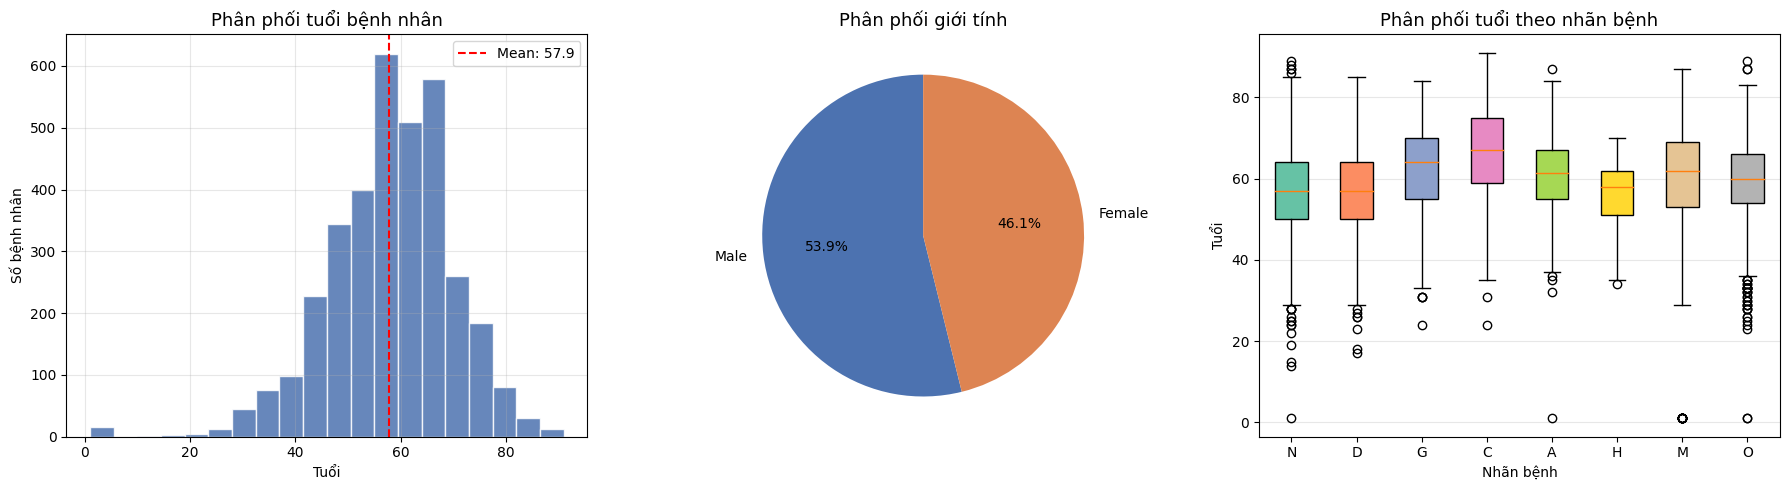

In [7]:
print('Age statistics:')
print(df['Patient Age'].describe())
print('\nGender distribution:')
print(df['Patient Sex'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram tuổi
axes[0].hist(df['Patient Age'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Patient Age'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["Patient Age"].mean():.1f}')
axes[0].set_title('Phân phối tuổi bệnh nhân', fontsize=13)
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Số bệnh nhân')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Pie giới tính
gender_counts = df['Patient Sex'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90)
axes[1].set_title('Phân phối giới tính', fontsize=13)

# Boxplot tuổi theo bệnh
age_by_disease = [df[df[col] == 1]['Patient Age'].values for col in TARGET_COLS]
bp = axes[2].boxplot(age_by_disease, labels=TARGET_COLS, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set2.colors[:len(TARGET_COLS)]):
    patch.set_facecolor(color)
axes[2].set_title('Phân phối tuổi theo nhãn bệnh', fontsize=13)
axes[2].set_xlabel('Nhãn bệnh')
axes[2].set_ylabel('Tuổi')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart_demographics.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Phương pháp Graham (Chuẩn hóa độ sáng)

Công thức: `out = addWeighted(img, 4, GaussianBlur(img, sigma), -4, 128)`

- Tạo ảnh mờ Gaussian → trừ đi từ ảnh gốc (× 4) → cộng bias 128
- Giúp làm nổi bật mạch máu và cấu trúc võng mạc
- **Quan trọng**: bias +128 giúp giữ pixel trong [0,255]; KHÔNG dùng phép trừ đơn thuần

In [8]:
def graham_preprocess(img_bgr, image_size=299, sigma_ratio=30):
    """
    Ben Graham's contrast normalization for fundus images.
    Formula: out = addWeighted(img, 4, GaussianBlur(img, sigma), -4, 128)
    The +128 bias keeps output in visible range (mean ~128).
    sigma = image_size / sigma_ratio (default: 299/30 ~ 10)
    """
    sigma   = image_size / sigma_ratio
    blurred = cv2.GaussianBlur(img_bgr, (0, 0), sigma)
    output  = cv2.addWeighted(img_bgr, 4, blurred, -4, 128)
    output  = cv2.resize(output, (image_size, image_size))
    return output

print('Graham function defined.')

Graham function defined.


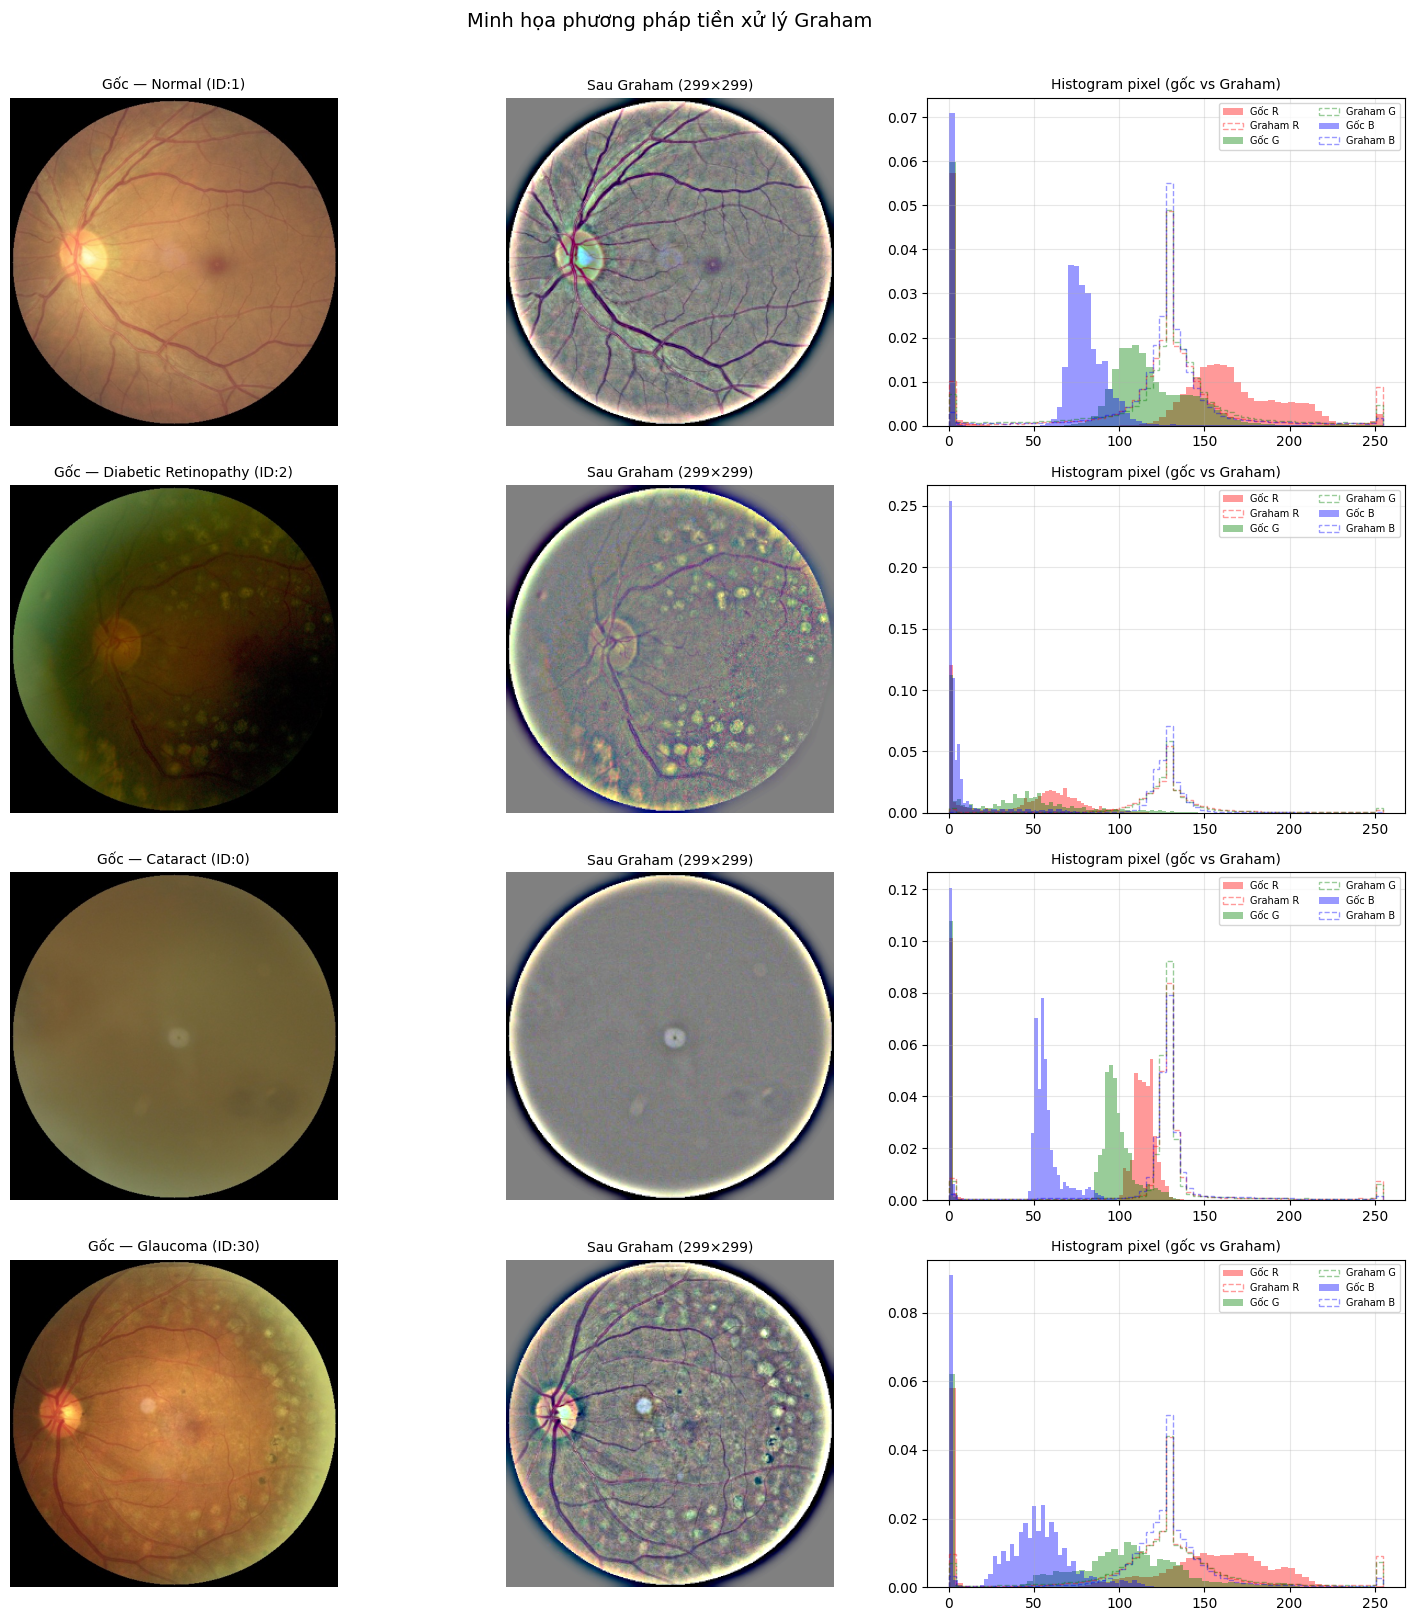

Saved: chart_graham_examples.png


In [9]:
# Minh họa trước/sau Graham cho các bệnh khác nhau
# Lấy 1 bệnh nhân từ mỗi bệnh: N, D, C, G
sample_diseases = ['N', 'D', 'C', 'G']
sample_pids = []
for disease in sample_diseases:
    pid = df[df[disease] == 1]['ID'].iloc[0]
    sample_pids.append((disease, pid))

fig, axes = plt.subplots(len(sample_pids), 3, figsize=(15, 4 * len(sample_pids)))

for row_idx, (disease, pid) in enumerate(sample_pids):
    img_path = f'{IMAGE_DIR}/{pid}_left.jpg'
    img_bgr  = cv2.imread(img_path)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    grah_bgr = graham_preprocess(img_bgr, image_size=299)
    grah_rgb = cv2.cvtColor(grah_bgr, cv2.COLOR_BGR2RGB)

    # Ảnh gốc
    axes[row_idx, 0].imshow(img_rgb)
    axes[row_idx, 0].set_title(f'Gốc — {LABEL_NAMES[disease]} (ID:{pid})', fontsize=10)
    axes[row_idx, 0].axis('off')

    # Ảnh Graham
    axes[row_idx, 1].imshow(grah_rgb)
    axes[row_idx, 1].set_title('Sau Graham (299×299)', fontsize=10)
    axes[row_idx, 1].axis('off')

    # Histogram so sánh
    for ch, color in enumerate(['red', 'green', 'blue']):
        axes[row_idx, 2].hist(img_rgb[:,:,ch].flatten(), bins=64, alpha=0.4,
                              color=color, label=f'Gốc {color[0].upper()}', density=True)
        axes[row_idx, 2].hist(grah_rgb[:,:,ch].flatten(), bins=64, alpha=0.4,
                              color=color, linestyle='--', histtype='step',
                              label=f'Graham {color[0].upper()}', density=True)
    axes[row_idx, 2].set_title('Histogram pixel (gốc vs Graham)', fontsize=10)
    axes[row_idx, 2].legend(fontsize=7, ncol=2)
    axes[row_idx, 2].grid(alpha=0.3)

plt.suptitle('Minh họa phương pháp tiền xử lý Graham', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart_graham_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: chart_graham_examples.png')

## 6. Tính Class Weights cho BCEWithLogitsLoss

In [10]:
# pos_weight_i = N_neg_i / N_pos_i
# Notebook này tính trên toàn bộ tập (chỉ để tham khảo)
# Class weights chính thức sẽ được tính trong notebook 02 từ tập train

N = len(df)
class_weights = {}
print('Class weights (pos_weight cho BCEWithLogitsLoss):')
print(f'{"Label":<5} {"Full Name":<38} {"N_pos":>6} {"N_neg":>6} {"Weight":>8}')
print('-' * 65)
for col in TARGET_COLS:
    n_pos = int(df[col].sum())
    n_neg = N - n_pos
    weight = round(n_neg / n_pos, 4)
    class_weights[col] = weight
    print(f'{col:<5} {LABEL_NAMES[col]:<38} {n_pos:>6} {n_neg:>6} {weight:>8.2f}')

weights_path = f'{OUTPUT_DIR}/class_weights_exploration.json'
with open(weights_path, 'w') as f:
    json.dump(class_weights, f, indent=2)
print(f'\nSaved: {weights_path}')

Class weights (pos_weight cho BCEWithLogitsLoss):
Label Full Name                               N_pos  N_neg   Weight
-----------------------------------------------------------------
N     Normal                                   1140   2360     2.07
D     Diabetic Retinopathy                     1128   2372     2.10
G     Glaucoma                                  215   3285    15.28
C     Cataract                                  212   3288    15.51
A     Age-related Macular Degeneration          164   3336    20.34
H     Hypertension                              103   3397    32.98
M     Myopia                                    174   3326    19.11
O     Other Diseases                            979   2521     2.58

Saved: /home/centrala/work/ou/kltn/Ocular-Disease-Recognition/model_v2/class_weights_exploration.json


## 7. Thống kê nhãn — lưu CSV

In [11]:
stats_rows = []
for col in TARGET_COLS:
    n_pos = int(df[col].sum())
    n_neg = N - n_pos
    stats_rows.append({
        'Label':       col,
        'Full Name':   LABEL_NAMES[col],
        'N_positive':  n_pos,
        'N_negative':  n_neg,
        'Percentage':  f'{df[col].mean()*100:.1f}%',
        'Pos_Weight':  class_weights[col],
    })
stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(f'{OUTPUT_DIR}/label_statistics.csv', index=False)
print('Saved: label_statistics.csv')
display(stats_df)

Saved: label_statistics.csv


,Label,Full Name,N_positive,N_negative,Percentage,Pos_Weight
0,N,Normal,1140,2360,32.6%,2.0702
1,D,Diabetic Retinopathy,1128,2372,32.2%,2.1028
2,G,Glaucoma,215,3285,6.1%,15.2791
3,C,Cataract,212,3288,6.1%,15.5094
4,A,Age-related Macular Degeneration,164,3336,4.7%,20.3415
5,H,Hypertension,103,3397,2.9%,32.9806
6,M,Myopia,174,3326,5.0%,19.1149
7,O,Other Diseases,979,2521,28.0%,2.5751


## 8. Kiểm tra kích thước ảnh

Width  — min: 512, max: 512, mean: 512
Height — min: 512, max: 512, mean: 512


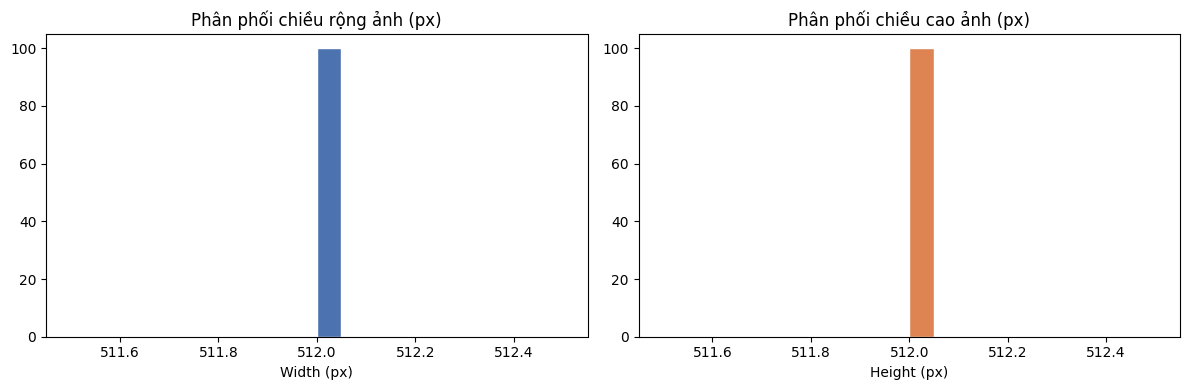

In [12]:
# Lấy mẫu 200 ảnh để kiểm tra kích thước
sample_pids_all = df['ID'].sample(min(100, len(df)), random_state=42).values
widths, heights = [], []
for pid in sample_pids_all:
    path = f'{IMAGE_DIR}/{pid}_left.jpg'
    if os.path.exists(path):
        img = Image.open(path)
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=20, color='#4C72B0', edgecolor='white')
axes[0].set_title('Phân phối chiều rộng ảnh (px)')
axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=20, color='#DD8452', edgecolor='white')
axes[1].set_title('Phân phối chiều cao ảnh (px)')
axes[1].set_xlabel('Height (px)')
plt.tight_layout()
plt.show()

## Tóm tắt

**Các file đã tạo:**
- `model_v2/chart_label_distribution.png` — phân phối nhãn
- `model_v2/chart_multilabel.png` — co-occurrence matrix
- `model_v2/chart_demographics.png` — nhân khẩu học
- `model_v2/chart_graham_examples.png` — minh họa tiền xử lý Graham
- `model_v2/label_statistics.csv` — thống kê nhãn
- `model_v2/class_weights_exploration.json` — class weights sơ bộ

**Bước tiếp theo:** Chạy `02_split_augmentation.ipynb`